# Level 3 — Task 3: NLP — Sentiment Analysis
**Codveda Technology | Data Analytics Internship**

> **Dataset:** `3_Sentiment_dataset.csv` | **Tools:** Python, nltk, TextBlob, pandas, matplotlib
>
> **Objective:** Preprocess text (tokenization, stopwords, lemmatization), perform sentiment analysis with TextBlob, and visualize sentiment distribution and word frequencies.


## Step 1 — Imports, Setup, and NLTK Downloads

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re, os, warnings

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.rcParams.update({
    "figure.dpi": 120
})

os.makedirs("outputs/level3/nlp_plots", exist_ok=True)

for resource in ["punkt", "stopwords", "wordnet", "punkt_tab", "omw-1.4"]:
    nltk.download(resource, quiet=True)

print("NLTK resources downloaded ✓")

NLTK resources downloaded ✓


## Step 2 — Load the Dataset

In [4]:
df = pd.read_csv("3_Sentiment_dataset.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df[["Text","Sentiment"]].head()

Shape: (732, 15)
Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


,Text,Sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral


## Step 3 — Normalize Granular Sentiments → Positive / Neutral / Negative

In [5]:
POSITIVE_KW = ["positive","joy","excitement","happy","contentment","hopeful",
               "gratitude","elation","playful","serenity","empowerment","enthusiasm",
               "satisfaction","inspired","proud","grateful","love","admiration",
               "accomplishment","celebration","hope","zest","thrill","amazement"]
NEGATIVE_KW = ["negative","sad","hate","bad","despair","loneliness","frustrated",
               "bitterness","anger","fear","sadness","disgust","disappointment",
               "grief","betrayal","sorrow","heartbreak","jealous","devastated",
               "overwhelmed","shame","anxiety","isolation","melancholy","exhaustion"]

def map_sentiment(s):
    s = str(s).lower().strip()
    for kw in POSITIVE_KW:
        if kw in s: return "Positive"
    for kw in NEGATIVE_KW:
        if kw in s: return "Negative"
    return "Neutral"

df["Sentiment_mapped"] = df["Sentiment"].apply(map_sentiment)
print("Normalized sentiment distribution:")
df["Sentiment_mapped"].value_counts()

Normalized sentiment distribution:


Sentiment_mapped
Neutral     341
Positive    274
Negative    117
Name: count, dtype: int64

## Step 4 — Text Preprocessing (Tokenization, Stopwords, Lemmatization)

In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text): return "", []
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    lemmas = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(lemmas), lemmas

processed = df["Text"].apply(preprocess_text)
df["clean_text"] = processed.apply(lambda x: x[0])
df["tokens"]     = processed.apply(lambda x: x[1])

print("Sample preprocessing:")
for _, row in df[["Text","clean_text"]].head(2).iterrows():
    print(f"  Before: {str(row['Text']).strip()[:70]}")
    print(f"  After : {row['clean_text'][:70]}\n")

Sample preprocessing:
  Before: Enjoying a beautiful day at the park!
  After : enjoying beautiful day park

  Before: Traffic was terrible this morning.
  After : traffic terrible morning



## Step 5 — TextBlob Sentiment Analysis

In [7]:
def get_sentiment(text):
    a = TextBlob(str(text))
    pol, sub = a.sentiment.polarity, a.sentiment.subjectivity
    label = "Positive" if pol > 0.05 else "Negative" if pol < -0.05 else "Neutral"
    return pol, sub, label

results = df["Text"].apply(get_sentiment)
df["tb_polarity"]     = results.apply(lambda x: x[0])
df["tb_subjectivity"] = results.apply(lambda x: x[1])
df["tb_sentiment"]    = results.apply(lambda x: x[2])

print("TextBlob sentiment distribution:")
print(df["tb_sentiment"].value_counts())
print(f"\nMean polarity    : {df['tb_polarity'].mean():.4f}")
print(f"Mean subjectivity: {df['tb_subjectivity'].mean():.4f}")

TextBlob sentiment distribution:
tb_sentiment
Neutral     342
Positive    271
Negative    119
Name: count, dtype: int64

Mean polarity    : 0.0984
Mean subjectivity: 0.3450


## Step 6 — Sentiment Distribution (Pie Charts)

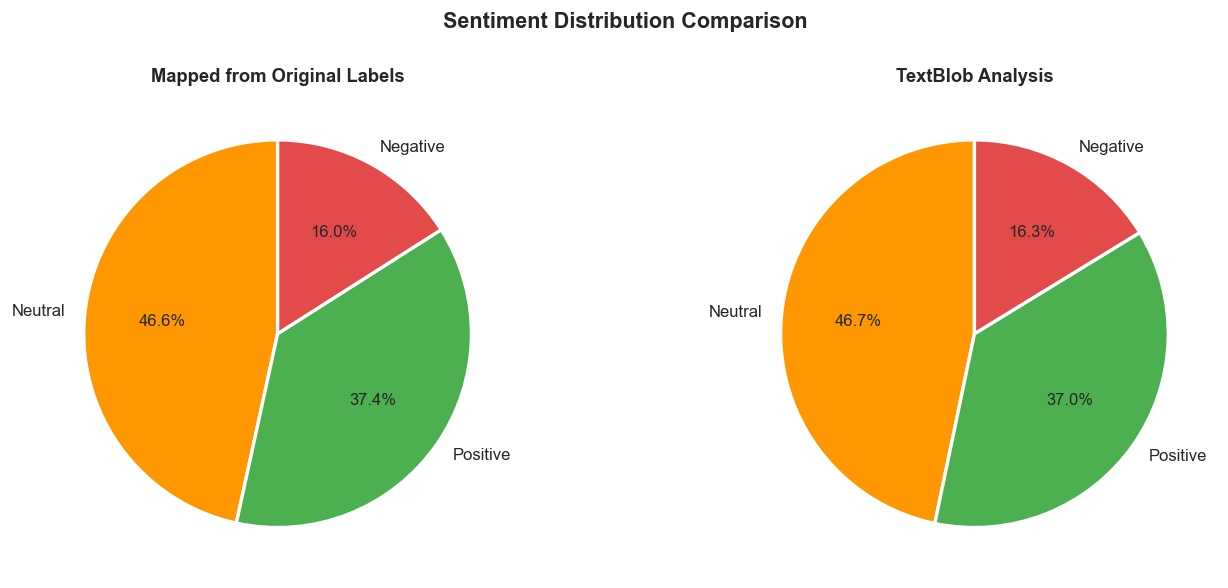

In [8]:
SENT_COLORS = {"Positive": "#4CAF50", "Neutral": "#FF9800", "Negative": "#E24B4A"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Sentiment Distribution Comparison", fontsize=13, fontweight="bold")

for ax, col, title in [
    (axes[0], "Sentiment_mapped", "Mapped from Original Labels"),
    (axes[1], "tb_sentiment",     "TextBlob Analysis"),
]:
    counts = df[col].value_counts()
    ax.pie(counts.values, labels=counts.index,
           colors=[SENT_COLORS.get(k,"#9E9E9E") for k in counts.index],
           autopct="%1.1f%%", startangle=90,
           wedgeprops={"edgecolor":"white","linewidth":2},
           textprops={"fontsize":10})
    ax.set_title(title, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/level3/nlp_plots/01_sentiment_distribution.png")
plt.show()

## Step 7 — Polarity vs Subjectivity Scatter

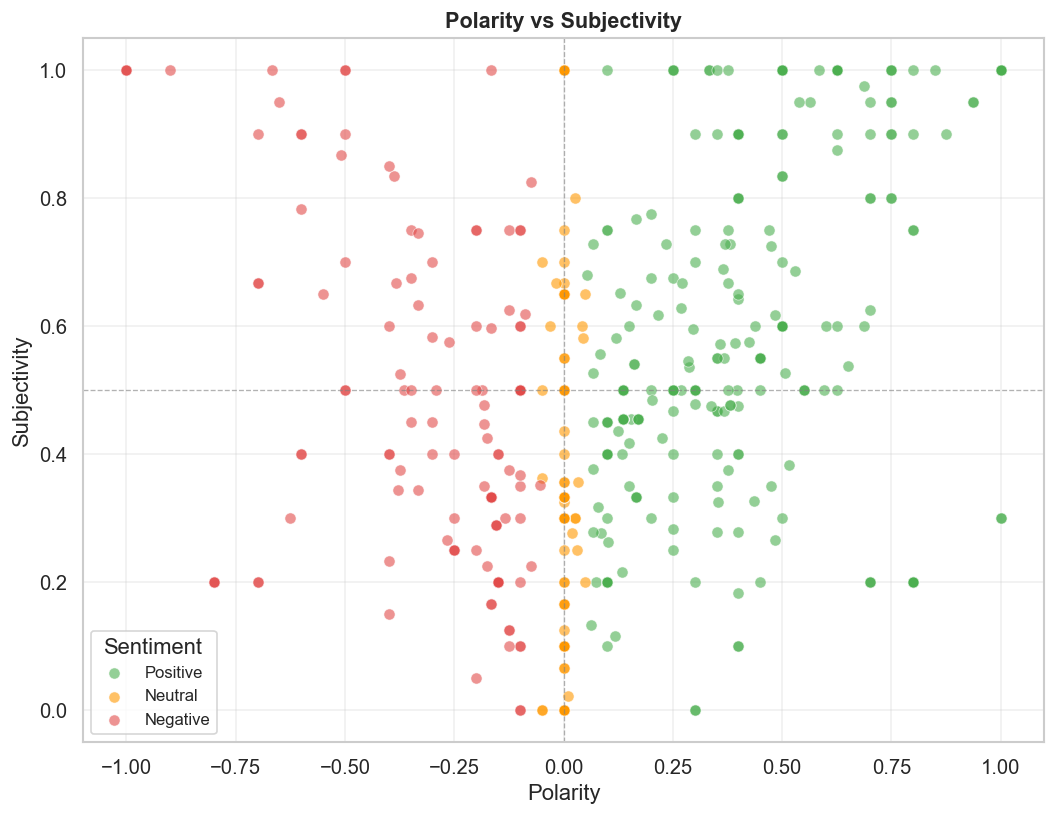

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
for sent, color in SENT_COLORS.items():
    mask = df["tb_sentiment"] == sent
    ax.scatter(df.loc[mask,"tb_polarity"], df.loc[mask,"tb_subjectivity"],
               color=color, label=sent, alpha=0.6, s=45,
               edgecolors="white", lw=0.5)
ax.axvline(0, color="gray", lw=0.8, ls="--", alpha=0.6)
ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.6)
ax.set_xlabel("Polarity"); ax.set_ylabel("Subjectivity")
ax.set_title("Polarity vs Subjectivity", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, title="Sentiment"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/level3/nlp_plots/03_polarity_subjectivity.png")
plt.show()

## Step 8 — Word Clouds per Sentiment

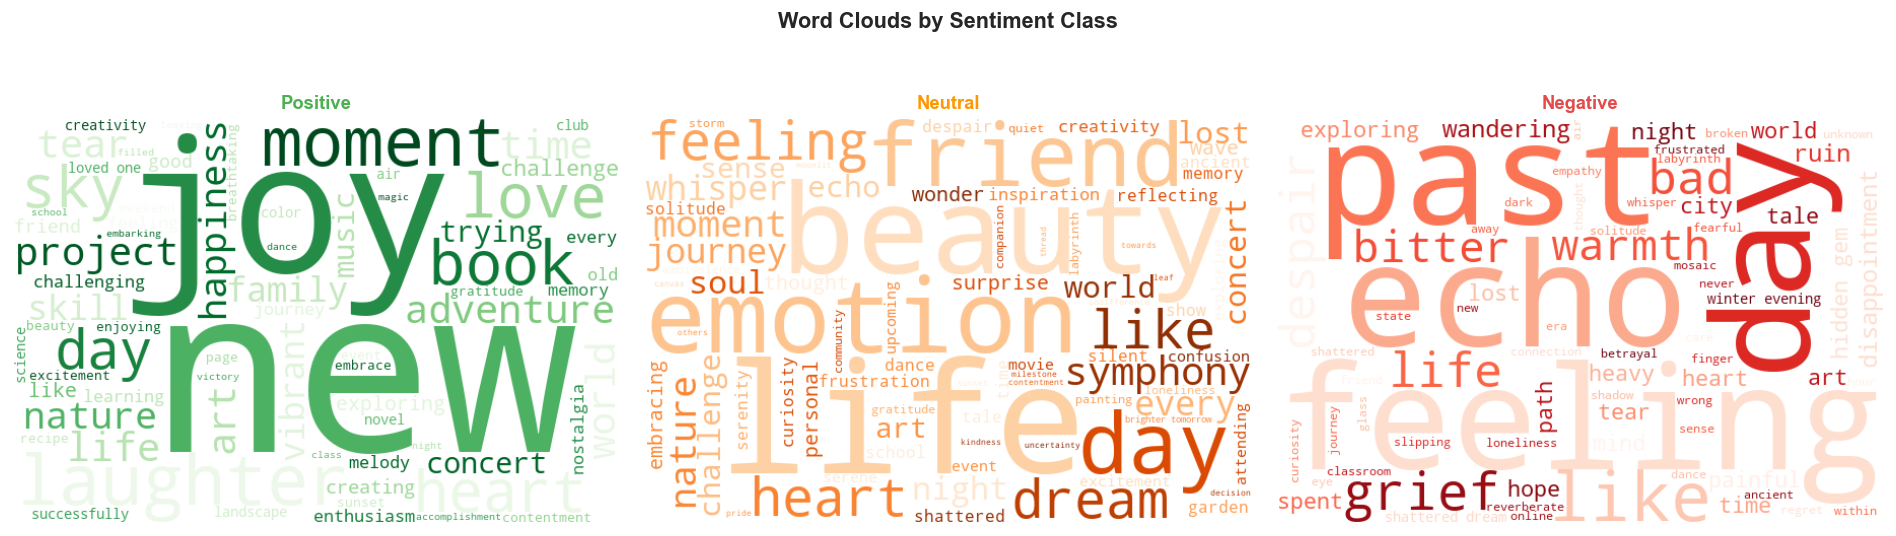

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Word Clouds by Sentiment Class", fontsize=13, fontweight="bold")

for ax, (sent, color) in zip(axes, SENT_COLORS.items()):
    text_blob = " ".join(df[df["tb_sentiment"]==sent]["clean_text"].dropna())
    if text_blob.strip():
        wc = WordCloud(width=600, height=400, background_color="white",
                       colormap="Greens" if sent=="Positive" else
                                "Oranges" if sent=="Neutral" else "Reds",
                       max_words=80, stopwords=stop_words, min_font_size=8
                       ).generate(text_blob)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{sent}", fontsize=11, fontweight="bold", color=color)

plt.tight_layout()
plt.savefig("outputs/level3/nlp_plots/04_word_clouds.png")
plt.show()

## Step 9 — Top 20 Words per Sentiment

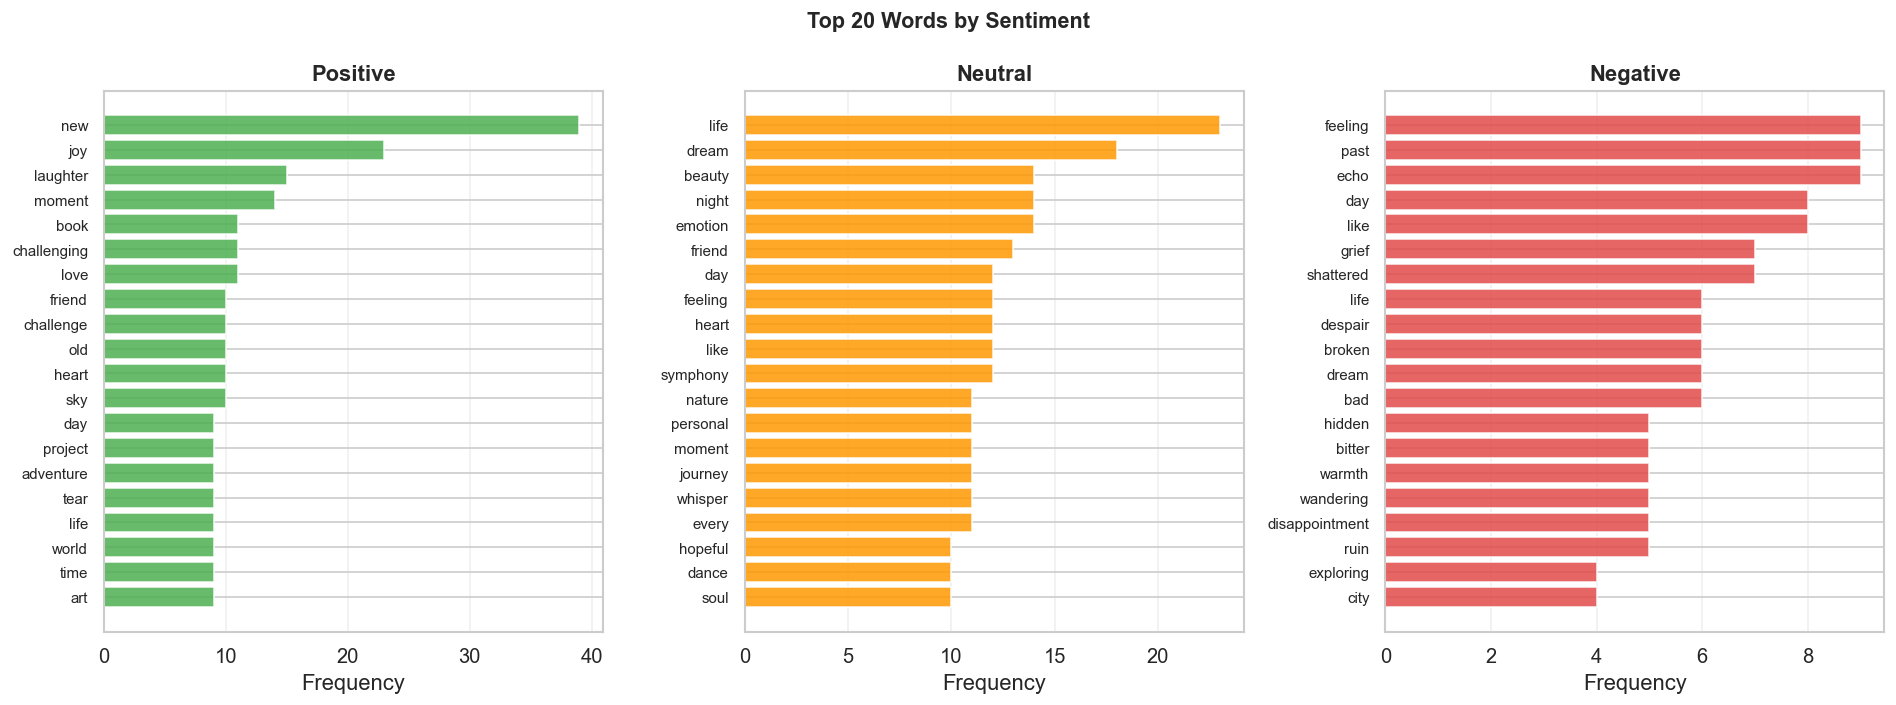

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Top 20 Words by Sentiment", fontsize=13, fontweight="bold")

for ax, (sent, color) in zip(axes, SENT_COLORS.items()):
    words = [w for tokens in df[df["tb_sentiment"]==sent]["tokens"].dropna() for w in tokens]
    freq = Counter(words).most_common(20)
    if freq:
        words_list, counts = zip(*freq)
        ax.barh(range(len(words_list)), counts, color=color, alpha=0.85, edgecolor="white")
        ax.set_yticks(range(len(words_list))); ax.set_yticklabels(words_list, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("Frequency"); ax.set_title(sent, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/level3/nlp_plots/05_top_words_by_sentiment.png")
plt.show()

## Step 10 — Platform × Sentiment Heatmap

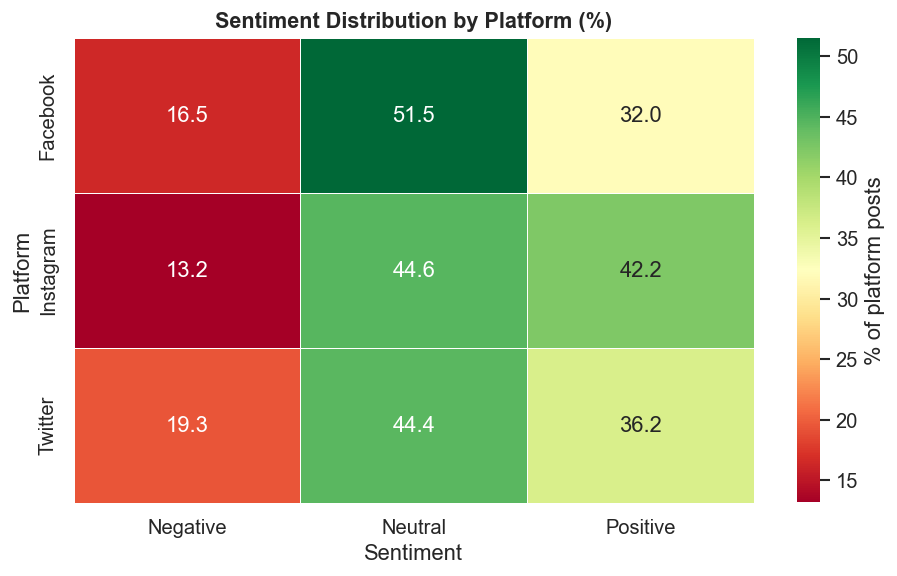

Results saved → outputs/level3/sentiment_results.csv


In [12]:
if "Platform" in df.columns:
    pivot = pd.crosstab(df["Platform"].str.strip(), df["tb_sentiment"],
                        normalize="index") * 100
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn",
                ax=ax, linewidths=0.5, cbar_kws={"label": "% of platform posts"})
    ax.set_title("Sentiment Distribution by Platform (%)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Sentiment"); ax.set_ylabel("Platform")
    plt.tight_layout()
    plt.savefig("outputs/level3/nlp_plots/06_platform_sentiment_heatmap.png")
    plt.show()

# Save results
df.to_csv("outputs/level3/sentiment_results.csv", index=False)
print("Results saved → outputs/level3/sentiment_results.csv")